# Arctic sea-ice thickness — a polar L4 map

Demonstrates the **surface-only polar-map pattern**: pull one day of
Arctic sea-ice thickness from the merged CryoSat-2 / SMOS L4 product and
render it as a map over the Arctic basin.

Dataset `esa_obs-si_arc_phy-sit_nrt_l4-multi_P1D-m` is near-real-time
and surface-only (no depth axis). Sea-ice **thickness** retrieval from
altimetry is winter-weighted — coverage is densest Oct–Apr — and the
NRT window rolls forward, so we probe a recent date and note that a
deep-summer re-run may need an earlier (winter) date.

Reads credentials from `COPERNICUSMARINE_SERVICE_USERNAME` /
`COPERNICUSMARINE_SERVICE_PASSWORD`.

In [1]:
import datetime as dt
import os
from pathlib import Path

import xarray as xr

from earthlens import EarthLens
from earthlens.cmems import Catalog
from pyramids.netcdf import NetCDF

OUT_DIR = Path('data/cmems-seaice')
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_ID = 'esa_obs-si_arc_phy-sit_nrt_l4-multi_P1D-m'
# ~45 days back keeps us inside the rolling NRT window; in deep summer
# bump this to a winter date (e.g. '2024-02-15') where SIT coverage is dense.
PROBE_DATE = (dt.datetime.now(dt.timezone.utc) - dt.timedelta(days=45)).strftime('%Y-%m-%d')

ds_meta = Catalog().get_dataset(DATASET_ID)
print(f'{DATASET_ID}: domain={ds_meta.domain}, cadence={ds_meta.cadence}')
print('variables:', sorted(ds_meta.variables))
print('probe date:', PROBE_DATE)

2026-05-20 19:42:58 | INFO | pyramids.base.config | Logging is configured.


esa_obs-si_arc_phy-sit_nrt_l4-multi_P1D-m: domain=polar, cadence=daily
variables: ['density_of_ocean', 'quality_flag', 'sea_ice_concentration', 'sea_ice_thickness', 'sea_ice_thickness_uncertainty', 'status_flag']
probe date: 2026-04-05


## Download one day over the Arctic basin

In [2]:
el = EarthLens(
    data_source='cmems',
    start=PROBE_DATE,
    end=PROBE_DATE,
    cadence='daily',
    dataset=DATASET_ID, variables=['sea_ice_thickness'],
    aoi=[-180.0, 65.0, 180.0, 88.0],
    path=str(OUT_DIR),
    service_username=os.environ.get('COPERNICUSMARINE_SERVICE_USERNAME'),
    service_password=os.environ.get('COPERNICUSMARINE_SERVICE_PASSWORD'),
)
paths = el.download()
print(paths)

INFO - 2026-05-20T17:43:03Z - Checking if credentials are valid.


2026-05-20 17:43:03 | INFO | copernicusmarine | Checking if credentials are valid.


INFO - 2026-05-20T17:43:03Z - Valid credentials from input username and password.


2026-05-20 17:43:03 | INFO | copernicusmarine | Valid credentials from input username and password.


2026-05-20 19:43:03.618 | INFO     | earthlens.cmems.backend:_subset_one:458 - Requesting CMEMS subset for 'esa_obs-si_arc_phy-sit_nrt_l4-multi_P1D-m' variables=['sea_ice_thickness'] → esa_obs-si_arc_phy-sit_nrt_l4-multi_P1D-m.nc


...

2026-05-20 17:43:04 | INFO | copernicusmarine | Selected dataset part: "default"


INFO - 2026-05-20T17:43:06Z - Total size of the download: 6.33 MB.


2026-05-20 17:43:06 | INFO | copernicusmarine | Total size of the download: 6.33 MB.


2026-05-20 19:43:06.586 | INFO     | earthlens.cmems.backend:download:326 - CMEMS download summary: 1 files written to C:\gdrive\algorithms\remote-sensing\earthlens\docs\examples\cmems\data\cmems-seaice


[WindowsPath('C:/gdrive/algorithms/remote-sensing/earthlens/docs/examples/cmems/data/cmems-seaice/esa_obs-si_arc_phy-sit_nrt_l4-multi_P1D-m.nc')]


## Open and inspect the field

The L4 grid is a polar stereographic projection, so the array carries
`xc` / `yc` projected axes (plus 2-D lat/lon). We collapse the single
time step and read the 2-D thickness field.

In [3]:
nc = NetCDF.read_file(str(paths[0]), read_only=True)
ds = xr.decode_cf(nc.to_xarray())
nc.close()
print('dims:', dict(ds.sizes))
sit = ds['sea_ice_thickness'].isel(time=0)
valid = sit.values[~__import__('numpy').isnan(sit.values)]
print(f'valid cells: {valid.size}')
if valid.size:
    print(f'thickness min/mean/max: {valid.min():.2f} / {valid.mean():.2f} / {valid.max():.2f} m')

dims: {'time': 1, 'latitude': 230, 'longitude': 3600}
valid cells: 474888
thickness min/mean/max: 0.04 / 1.89 / 4.67 m


## Map the thickness field

A plain `pcolormesh` of the projected grid — thicker multi-year ice
north of the Canadian Arctic Archipelago, thinner first-year ice toward
the marginal seas.

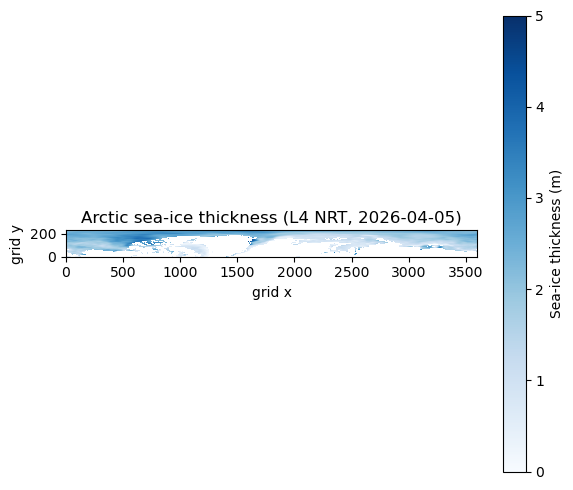

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
mesh = ax.pcolormesh(sit.values, cmap='Blues', vmin=0, vmax=5)
fig.colorbar(mesh, ax=ax, label='Sea-ice thickness (m)')
ax.set_title(f'Arctic sea-ice thickness (L4 NRT, {PROBE_DATE})')
ax.set_xlabel('grid x')
ax.set_ylabel('grid y')
ax.set_aspect('equal')
fig.tight_layout()